## What are the most demand skills for the top 3 most popular data roles 

#### Methodology

###### 1. Clean-up skill column 
###### 2. Calculate skill count based on job_title_short
###### 3. Calculate skill percentage
###### 4. Plot final findings

In [25]:
import ast 
import seaborn as sns 
import pandas as pd 
import matplotlib.pyplot as plt 

data = pd.read_csv(r"C:\Users\Lenovo\OneDrive\Documents\Projects\Luke Barousse Projects\Python Course  Data Analysis\data_jobs.csv")
df=data
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)


In [3]:
df_US = df[df['job_country'] == "United States"]

In [4]:
df_skills = df_US.explode('job_skills')
df_skills[['job_title','job_skills']]

,job_title,job_skills
4,Technical Data Analyst,sql
4,Technical Data Analyst,python
4,Technical Data Analyst,jira
6,Research Data Scientist - Now Hiring,python
6,Research Data Scientist - Now Hiring,r
...,...,...
787623,Data Analyst,sas
787623,Data Analyst,sas
787623,Data Analyst,excel
787623,Data Analyst,powerpoint


In [5]:
df_skills_count=df_skills.groupby(['job_skills','job_title_short']).size()
df_skills_count = df_skills_count.reset_index(name='skill_count')


In [6]:
df_skills_count.sort_values(by='skill_count',ascending=False,inplace= True)
df_skills_count

,job_skills,job_title_short,skill_count
1207,python,Data Scientist,42497
1519,sql,Data Analyst,34504
1521,sql,Data Scientist,30073
456,excel,Data Analyst,27579
1241,r,Data Scientist,26111
...,...,...,...
619,graphql,Senior Data Analyst,1
628,groovy,Senior Data Scientist,1
623,groovy,Business Analyst,1
1838,workfront,Data Engineer,1


In [9]:
job_titles = df_skills_count['job_title_short'].unique().tolist()
job_titles=sorted(job_title[:3])

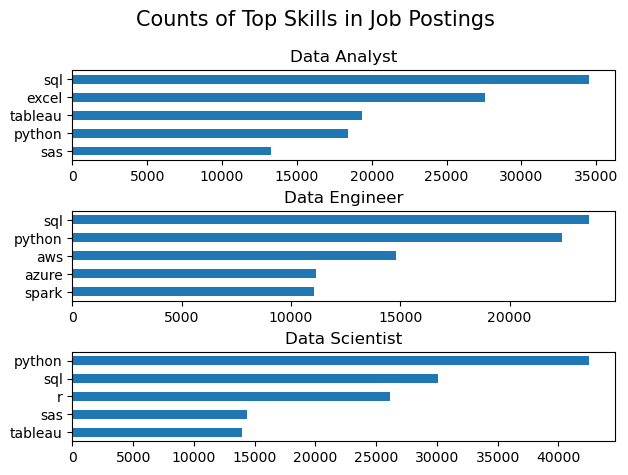

In [18]:
fig,ax = plt.subplots(len(job_titles),1)

for i,job_title in enumerate(job_titles):
    df_plot= df_skills_count[df_skills_count['job_title_short']==job_title].head(5)
    df_plot.plot(kind='barh',x='job_skills',y='skill_count',ax=ax[i],title=job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
fig.suptitle('Counts of Top Skills in Job Postings',fontsize=15)
plt.tight_layout(h_pad=0.5)
plt.show()

In [22]:
df_job_title_count=df_US['job_title_short'].value_counts().reset_index(name='jobs_total')
df_job_title_count

,job_title_short,jobs_total
0,Data Analyst,67939
1,Data Scientist,58977
2,Data Engineer,34620
3,Senior Data Scientist,12977
4,Senior Data Analyst,11838
5,Senior Data Engineer,9231
6,Business Analyst,7393
7,Software Engineer,1809
8,Machine Learning Engineer,939
9,Cloud Engineer,422


In [21]:
df_skills_perc=pd.merge(df_skills_count,df_job_title_count,how='left',on='job_title_short')
df_skills_perc['skill_percent'] = 100* df_skills_perc['skill_count'] / df_skills_perc['jobs_total']
df_skills_perc

,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,python,Data Scientist,42497,58977,72.056904
1,sql,Data Analyst,34504,67939,50.786735
2,sql,Data Scientist,30073,58977,50.991064
3,excel,Data Analyst,27579,67939,40.593768
4,r,Data Scientist,26111,58977,44.273191
...,...,...,...,...,...
1864,graphql,Senior Data Analyst,1,11838,0.008447
1865,groovy,Senior Data Scientist,1,12977,0.007706
1866,groovy,Business Analyst,1,7393,0.013526
1867,workfront,Data Engineer,1,34620,0.002889


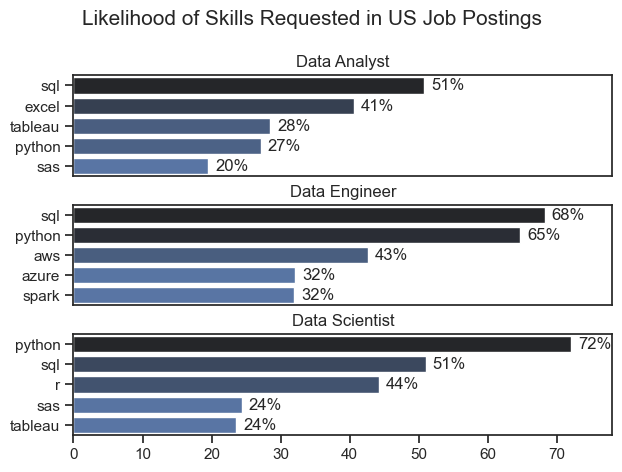

In [41]:
fig,ax = plt.subplots(len(job_titles),1)

sns.set_theme(style='ticks')
for i,job_title in enumerate(job_titles):
    df_plot= df_skills_perc[df_skills_perc['job_title_short']==job_title].head(5)
    # df_plot.plot(kind='barh',x='job_skills',y='skill_percent',ax=ax[i],title=job_title)
    sns.barplot(data=df_plot,x='skill_percent',y='job_skills',ax=ax[i],hue='skill_count',palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0,78)

    for n,v in enumerate(df_plot['skill_percent']):
        ax[i].text(v+1,n,f'{v:.0f}%',va='center')

    if i != len(job_titles)-1:
        ax[i].set_xticks([])
fig.suptitle('Likelihood of Skills Requested in US Job Postings',fontsize=15)
plt.tight_layout(h_pad=0.5)
plt.show()